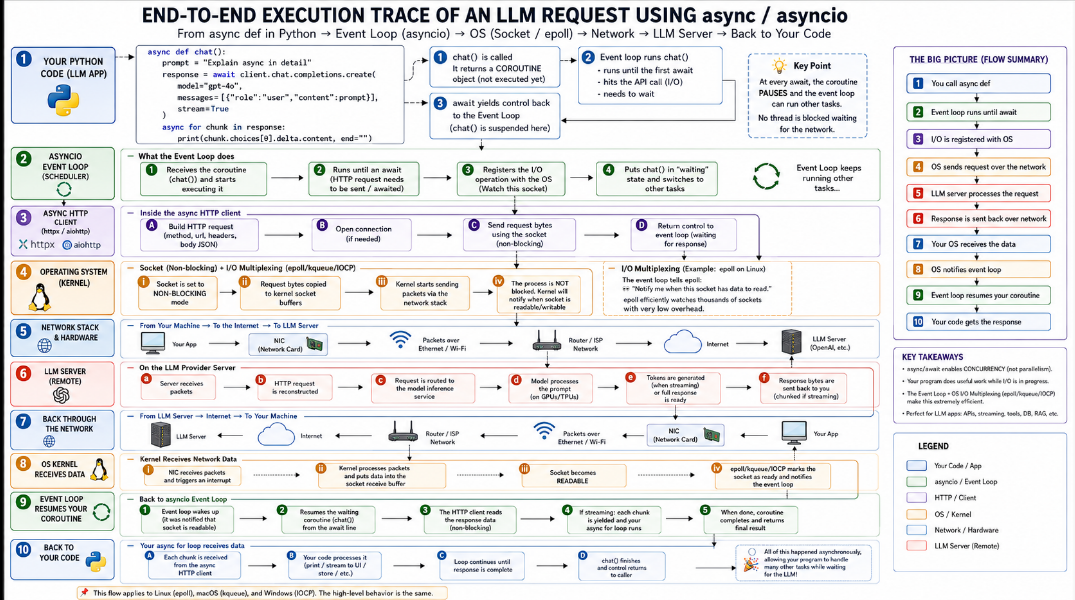

 ## 1) Why `async` was made at all

Computers are very fast at **executing instructions**, but many real programs spend most of their time **waiting**:

* waiting for a network response
* waiting for disk
* waiting for a database
* waiting for another process
* waiting for user input

An LLM app is full of waiting:

* sending a prompt to an API
* retrieving documents from a vector database
* calling tools
* streaming tokens
* querying a database
* making multiple model calls in an agent loop

The problem is this:

If your program uses a normal blocking style, one request can sit idle while the CPU does nothing useful. `async` was created to let one program manage many waiting tasks efficiently **without creating a thread for each one**.

So the main goal is:

> **Do useful work while other operations are waiting.**

That is the whole reason `async` exists.

---

## 2) The big idea: waiting is the expensive part

Suppose you ask an LLM API for a response.

Inside that call, your Python code is usually not “thinking.” It is mostly:

1. building an HTTP request
2. sending bytes to the network stack
3. waiting for a reply
4. receiving bytes back
5. parsing the response

During steps 2–4, your CPU could be almost idle.

Without async, your program often blocks:

* it waits on one request
* nothing else runs in that thread
* the whole worker is stuck

With async:

* the request starts
* control returns to the event loop
* other tasks run while the first one waits
* when the data is ready, execution resumes

That is why async is such a good fit for LLM systems.

---

## 3) Concurrency vs parallelism

These two are not the same.

### Concurrency

Multiple tasks are **in progress** at the same time.

Example:

* request A started
* request B started
* request C started
* while A waits, B runs
* while B waits, C runs

### Parallelism

Multiple tasks run **literally at the same instant** on different CPU cores.

Async is mainly about **concurrency**, not true CPU parallelism.

This matters because LLM applications are often:

* network-heavy
* I/O-heavy
* latency-sensitive

That is exactly where concurrency helps a lot.

---

## 4) What happens at the hardware level

Let us go from Python all the way down to hardware.

### A. Your program calls the network

When your code sends a request to an LLM API, it usually writes data to a socket.

A socket is like a communication endpoint managed by the operating system.

### B. The operating system takes over

The kernel handles the network stack:

* packet creation
* routing
* retransmission
* TCP state
* acknowledgements

Your Python program does not manually move packets through wires. The OS and network hardware do that.

### C. Network card and interrupts

The NIC (network interface card) sends and receives packets. When packets arrive, hardware can notify the CPU using interrupts or similar mechanisms.

### D. CPU does not sit and spin

In a blocking call, your process may sleep while the kernel waits for the network reply.

In async, the process does not keep one thread blocked per request. Instead, it registers interest in “tell me when this socket is readable/writable.”

### E. Event notification

Modern operating systems provide efficient notification systems:

* Linux: `epoll`
* macOS/BSD: `kqueue`
* Windows: IOCP

These let a program ask:

> “Wake me up only when this socket has data.”

That is the foundation of async I/O.

So at the hardware/OS level, async is basically a smarter way to wait for external events without wasting threads.

---

## 5) What `async def` really means in Python

When you write:

```python
async def fetch():
    ...
```

you are not writing a normal function.

You are defining a **coroutine function**.

Calling it does **not** run it immediately.

```python
coro = fetch()
```

This gives you a coroutine object, which is like a paused computation that can be resumed later.

The keyword `await` means:

> “Pause this coroutine here, give control back to the event loop, and resume me later when this awaited thing is ready.”

So this:

```python
result = await api_call()
```

means:

* start `api_call`
* if it is not ready yet, suspend this coroutine
* let other tasks run
* resume when `api_call` finishes

---

## 6) How Python async works internally

This is the important part.

An `async def` function behaves a bit like a generator, but more advanced.

### It becomes a state machine

Python saves the function’s execution state:

* local variables
* current line number
* what it is waiting on
* call stack information for the coroutine

So instead of “stopping” like a normal function, it is **paused** and can be resumed later from exactly the same point.

That is why `await` works.

You can think of it like this:

* normal function = run from start to finish without interruption
* coroutine = run until an `await`, pause, then continue later

---

## 7) What is the event loop?

The event loop is the heart of `asyncio`.

It is a scheduler that repeatedly does something like this:

1. check which I/O operations are ready
2. resume the coroutines waiting for those operations
3. run them until they hit another `await`
4. repeat forever

So the event loop is like a traffic controller for many coroutines.

Very simplified:

```python
while True:
    ready_tasks = get_ready_io_events()
    for task in ready_tasks:
        task.resume()
```

In reality it is more complex, but this is the core idea.

---

## 8) Why this is faster than threads for I/O

You might ask: why not just use threads?

Threads also allow waiting tasks to overlap. But threads have overhead:

* memory per thread
* stack space
* context switching cost
* synchronization complexity
* race conditions
* locks
* deadlocks

For thousands of concurrent network requests, threads become heavier.

Async coroutines are much lighter:

* one thread can manage many tasks
* switching between coroutines is cheap
* no OS thread context switch is needed for each coroutine switch

This is why async is great for:

* APIs
* web servers
* chat systems
* streaming tokens
* crawlers
* RAG pipelines

---

## 9) What `asyncio` is

`asyncio` is Python’s built-in library for:

* running the event loop
* creating tasks
* awaiting futures
* coordinating async operations
* scheduling timeouts and cancellation

The important parts:

### `await`

Pause until something is ready.

### `asyncio.create_task()`

Start a coroutine in the background, letting it run concurrently.

### `asyncio.gather()`

Run multiple coroutines together and collect results.

### `asyncio.sleep()`

Non-blocking sleep. The event loop can do other things during the wait.

---

## 10) How a real async call flows in an LLM app

Suppose you have this:

```python
response = await client.chat.completions.create(...)
```

What is happening underneath?

### Step 1: Build request

Python creates the HTTP request body.

### Step 2: Send over socket

The socket write may not finish immediately, so the OS may say:

* writable now
* or try again later

### Step 3: Yield control

If the request cannot continue right away, the coroutine pauses.

### Step 4: Event loop watches the socket

The event loop asks the OS:

* tell me when this socket has data to read

### Step 5: Network response arrives

The NIC receives packets, kernel processes them, and the socket becomes readable.

### Step 6: Event loop resumes coroutine

Python continues from the `await` line.

### Step 7: Parse response

The body is decoded and returned to your code.

This is the essence of async networking.

---

## 11) Why LLM systems benefit so much

LLM apps usually combine many waiting operations:

* model call
* retrieval from vector DB
* document loading
* web search
* database query
* tool execution
* streaming response to the client

If you do them one by one synchronously, total latency stacks up.

Example:

* web search: 1.5 s
* vector search: 0.8 s
* SQL query: 0.5 s
* LLM call: 3.0 s

Synchronous sequential time:

* 1.5 + 0.8 + 0.5 + 3.0 = 5.8 s

Async concurrent time:

* often close to the slowest step, around 3.0 s plus overhead

That can make an app feel much faster.

---

## 12) Streaming tokens is also a good fit

In LLM apps, you often stream tokens to the UI.

That means:

* model generates a chunk
* send it to frontend
* continue generating
* send next chunk

Async helps because the server can:

* receive partial output
* push it immediately to the client
* keep the connection open without blocking other users

This is one reason FastAPI and other async web frameworks are popular in AI apps.

---

## 13) Important limitation: async does not make CPU-heavy work magically faster

This is a huge thing to know.

If your task is CPU-heavy, like:

* tokenization on huge data
* image processing
* large embeddings computation in pure Python
* heavy math
* training
* local inference in Python loops

then async is not the main solution.

Why?

Because the CPU is busy computing, not waiting.

Async is best when you are **waiting on I/O**.

For CPU-heavy work, use:

* multiprocessing
* native libraries
* GPU acceleration
* compiled extensions
* task queues
* worker processes

---

## 14) Python and the GIL

You should know this because people mention it a lot.

Python’s CPython implementation has the **GIL**: Global Interpreter Lock.

That means:

* one thread at a time executes Python bytecode in a single process

This sounds bad, but for async I/O it is fine because:

* the program is mostly waiting, not computing
* the event loop can manage many tasks in one thread

So:

* async is excellent for I/O-bound concurrency
* threads are limited by GIL for CPU-bound work
* multiprocessing avoids the GIL by using multiple processes

---

## 15) What `async` is not

It is not:

* automatic multithreading
* automatic parallel GPU use
* a magic speed booster for every program
* a replacement for all threads

It is a structured way to handle waiting efficiently.

---

## 16) What `await` really means in practice

Whenever you see `await`, think:

> “This point may pause here so the rest of the program can continue.”

Example:

```python
async def handler():
    user = await get_user()
    docs = await retrieve_docs(user.query)
    answer = await llm_call(user.query, docs)
    return answer
```

Each `await` is a checkpoint.

At each checkpoint:

* the coroutine may pause
* the event loop can run other tasks
* later it resumes from the same line

---

## 17) Why async functions must be called carefully

You cannot just call an async function like a normal one.

This:

```python
result = fetch()
```

gives you a coroutine object, not the result.

You need:

```python
result = await fetch()
```

or schedule it with the event loop.

That design is intentional. It forces you to think about when the program can pause.

---

## 18) `asyncio.gather()` and task scheduling

Suppose you need to call three tools in parallel:

```python
results = await asyncio.gather(
    search_web(),
    search_db(),
    call_llm()
)
```

What happens is:

* all three coroutines start
* each runs until its first `await`
* the event loop switches between them
* when each one is done, `gather` collects the outputs

This is not three OS threads in the usual sense. It is one event loop coordinating many paused computations.

---

## 19) Cancellation and timeouts

Another important reason async exists is control.

In LLM apps, you need to stop slow or stuck work.

For example:

* user closes browser tab
* tool call takes too long
* model API stalls
* retrieval hangs

Async gives you:

* cancellation
* timeouts
* graceful shutdown
* backpressure handling

Example:

```python
await asyncio.wait_for(llm_call(), timeout=10)
```

This says:

* if it takes too long, stop it

That is very useful in production.

---

## 20) Backpressure in streaming systems

In a real LLM app, the model may generate faster than the client can receive.

Async helps you manage that:

* if downstream is slow, the event loop can pause writes
* the system avoids building huge buffers
* memory stays controlled

This matters a lot in large-scale chat systems.

---

## 21) A mental model that is actually accurate

Think of async like this:

A restaurant has:

* one head waiter
* many customers
* many dishes cooking in parallel in the kitchen

The waiter:

* takes an order
* gives it to kitchen
* moves on to another table
* comes back when food is ready

The waiter is the event loop.
The cooking dishes are the waiting I/O tasks.
The tables are your coroutines.

The waiter is not cooking every dish personally. It is coordinating many waiting jobs efficiently.

---

## 22) Why it matters specifically in LLM code

In LLM systems, most latency is often outside the model math itself:

* network round trips
* retrieval
* tool calls
* formatting
* post-processing
* multiple agent steps

So async gives you:

* faster perceived response time
* better throughput
* lower resource waste
* cleaner handling of streaming and cancellation

That is why almost every serious AI backend eventually runs into async.

---

## 23) The practical rule of thumb

Use `async` when the code spends time waiting on:

* network
* disk
* database
* APIs
* model inference over HTTP
* streaming connections

Do not expect `async` to speed up:

* heavy number crunching
* training loops in pure Python
* large CPU-bound transformations

---

## 24) What you should remember

If you remember only five things, remember these:

1. `async` exists to handle waiting efficiently.
2. `await` pauses a coroutine and lets other tasks run.
3. `asyncio` is the event-loop system that schedules those coroutines.
4. It is best for I/O-bound work, especially LLM APIs and web services.
5. It does not replace parallel computing for CPU-heavy tasks.

---

## 25) The most honest one-line definition

`async/await` is a way to write code that can pause at waiting points, let other work happen, and resume later, so one thread can efficiently manage many I/O tasks.
